# Sales Analysis with Python

## Project Objective

The objective of this project is to analyze sales transaction data using Python and identify patterns in revenue, customers, products, categories, regions, discounts and time.

### Key Business Questions

- What is the overall revenue performance?
- Which products and categories generate the most revenue?
- Which regions contribute the most revenue?
- Which customers generate the highest value?
- How does revenue change over time?
- What factors are associated with changes in revenue?
- How are discounts distributed across categories?

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [136]:
df = pd.read_csv("../data/sales.csv")

df.head()

,order_id,order_date,customer_id,product,category,quantity,price,discount,region
0,1001,2026-01-03,C001,Laptop,Electronics,2,55000,0.05,North
1,1002,2026-01-05,C002,Mouse,Accessories,5,800,0.00,South
2,1003,2026-01-07,C003,Keyboard,Accessories,3,1500,0.10,East
3,1004,2026-01-10,C001,Monitor,Electronics,1,18000,0.05,North
4,1005,2026-01-13,C004,Office Chair,Furniture,2,8500,0.15,West


In [137]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 30
Columns: 9


In [138]:
df.columns.tolist()

['order_id',
 'order_date',
 'customer_id',
 'product',
 'category',
 'quantity',
 'price',
 'discount',
 'region']

In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     30 non-null     int64  
 1   order_date   30 non-null     str    
 2   customer_id  30 non-null     str    
 3   product      30 non-null     str    
 4   category     30 non-null     str    
 5   quantity     30 non-null     int64  
 6   price        30 non-null     int64  
 7   discount     30 non-null     float64
 8   region       30 non-null     str    
dtypes: float64(1), int64(3), str(5)
memory usage: 2.2 KB


In [140]:
df.describe()

,order_id,quantity,price,discount
count,30.00,30.00,30.00,30.00
mean,"1,015.50",2.27,"19,146.67",0.05
std,8.80,1.36,"19,715.72",0.05
min,"1,001.00",1.00,800.00,0.00
25%,"1,008.25",1.00,"2,500.00",0.00
50%,"1,015.50",2.00,"12,000.00",0.05
75%,"1,022.75",3.00,"28,000.00",0.10
max,"1,030.00",6.00,"60,000.00",0.15


In [141]:
print("Missing values:")
display(df.isna().sum())

Missing values:


order_id       0
order_date     0
customer_id    0
product        0
category       0
quantity       0
price          0
discount       0
region         0
dtype: int64

In [142]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [143]:
print("Duplicate Order IDs:", df["order_id"].duplicated().sum())

Duplicate Order IDs: 0


In [144]:
df["order_date"] = pd.to_datetime(df["order_date"])

print("Invalid dates:", df["order_date"].isna().sum())
print("Minimum date:", df["order_date"].min())
print("Maximum date:", df["order_date"].max())

Invalid dates: 0
Minimum date: 2026-01-03 00:00:00
Maximum date: 2026-04-21 00:00:00


In [145]:
# 6. Feature Engineering

df["revenue"] = (
    df["quantity"]
    * df["price"]
    * (1 - df["discount"])
)

df.head()


,order_id,order_date,customer_id,product,category,quantity,price,discount,region,revenue
0,1001,2026-01-03,C001,Laptop,Electronics,2,55000,0.05,North,"104,500.00"
1,1002,2026-01-05,C002,Mouse,Accessories,5,800,0.00,South,"4,000.00"
2,1003,2026-01-07,C003,Keyboard,Accessories,3,1500,0.10,East,"4,050.00"
3,1004,2026-01-10,C001,Monitor,Electronics,1,18000,0.05,North,"17,100.00"
4,1005,2026-01-13,C004,Office Chair,Furniture,2,8500,0.15,West,"14,450.00"


In [146]:
print("Minimum revenue:", df["revenue"].min())
print("Zero-revenue orders:", (df["revenue"] == 0).sum())
print("Negative-revenue orders:", (df["revenue"] < 0).sum())

Minimum revenue: 3200.0
Zero-revenue orders: 0
Negative-revenue orders: 0


In [147]:
total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
unique_customers = df["customer_id"].nunique()
average_order_value = total_revenue / total_orders

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")

Total Revenue: ₹819,050.00
Total Orders: 30
Unique Customers: 12
Average Order Value: ₹27,301.67


In [148]:
customer_revenue = (
    df.groupby("customer_id")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

customer_revenue

customer_id
C007   156,400.00
C001   155,800.00
C010    94,700.00
C011    87,400.00
C005    75,750.00
C004    66,950.00
C012    43,500.00
C006    42,450.00
C009    34,350.00
C008    26,800.00
C003    21,700.00
C002    13,250.00
Name: revenue, dtype: float64

In [149]:
customer_analysis = (
    df.groupby("customer_id")
      .agg(
          orders=("order_id", "nunique"),
          revenue=("revenue", "sum")
      )
)

customer_analysis["aov"] = (
    customer_analysis["revenue"]
    / customer_analysis["orders"]
)

customer_analysis = customer_analysis.sort_values(
    "revenue",
    ascending=False
)

customer_analysis

,orders,revenue,aov
customer_id,,,
C007,2,"156,400.00","78,200.00"
C001,3,"155,800.00","51,933.33"
C010,2,"94,700.00","47,350.00"
C011,2,"87,400.00","43,700.00"
C005,3,"75,750.00","25,250.00"
C004,3,"66,950.00","22,316.67"
C012,2,"43,500.00","21,750.00"
C006,3,"42,450.00","14,150.00"
C009,2,"34,350.00","17,175.00"


In [150]:
top5_customer_share = (
    customer_analysis.head(5)["revenue"].sum()
    / total_revenue
    * 100
)

print(f"Top 5 customers revenue share: {top5_customer_share:.2f}%")

Top 5 customers revenue share: 69.60%


In [151]:
def customer_segment(revenue):
    if revenue >= 75000:
        return "High Value"
    elif revenue >= 40000:
        return "Medium Value"
    else:
        return "Low Value"


customer_analysis["segment"] = (
    customer_analysis["revenue"]
    .apply(customer_segment)
)

customer_analysis

,orders,revenue,aov,segment
customer_id,,,,
C007,2,"156,400.00","78,200.00",High Value
C001,3,"155,800.00","51,933.33",High Value
C010,2,"94,700.00","47,350.00",High Value
C011,2,"87,400.00","43,700.00",High Value
C005,3,"75,750.00","25,250.00",High Value
C004,3,"66,950.00","22,316.67",Medium Value
C012,2,"43,500.00","21,750.00",Medium Value
C006,3,"42,450.00","14,150.00",Medium Value
C009,2,"34,350.00","17,175.00",Low Value


In [152]:
segment_revenue = (
    customer_analysis
    .groupby("segment")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue_share = (
    segment_revenue / total_revenue * 100
)

segment_revenue_share

segment
High Value     69.60
Medium Value   18.67
Low Value      11.73
Name: revenue, dtype: float64

In [153]:
product_analysis = (
    df.groupby("product")
      .agg(
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum"),
          revenue=("revenue", "sum")
      )
      .sort_values("revenue", ascending=False)
)

product_analysis["revenue_per_unit"] = (
    product_analysis["revenue"]
    / product_analysis["quantity"]
)

product_analysis["revenue_share"] = (
    product_analysis["revenue"]
    / total_revenue
    * 100
)

product_analysis

,orders,quantity,revenue,revenue_per_unit,revenue_share
product,,,,,
Laptop,5,7,"377,800.00","53,971.43",46.13
Phone,3,4,"114,100.00","28,525.00",13.93
Monitor,3,5,"87,300.00","17,460.00",10.66
Desk,4,6,"70,200.00","11,700.00",8.57
Tablet,2,3,"61,600.00","20,533.33",7.52
Office Chair,4,8,"59,500.00","7,437.50",7.26
Headphones,3,9,"21,250.00","2,361.11",2.59
Keyboard,3,11,"15,300.00","1,390.91",1.87
Mouse,3,15,"12,000.00",800.00,1.47


In [154]:
quantity_median = product_analysis["quantity"].median()
revenue_median = product_analysis["revenue"].median()

In [155]:
def product_segment(row):
    if (
        row["quantity"] >= quantity_median
        and row["revenue"] >= revenue_median
    ):
        return "High Volume - High Revenue"

    elif (
        row["quantity"] >= quantity_median
        and row["revenue"] < revenue_median
    ):
        return "High Volume - Low Revenue"

    elif (
        row["quantity"] < quantity_median
        and row["revenue"] >= revenue_median
    ):
        return "Low Volume - High Revenue"

    else:
        return "Low Volume - Low Revenue"


product_analysis["segment"] = (
    product_analysis
    .apply(product_segment, axis=1)
)

product_analysis

,orders,quantity,revenue,revenue_per_unit,revenue_share,segment
product,,,,,,
Laptop,5,7,"377,800.00","53,971.43",46.13,High Volume - High Revenue
Phone,3,4,"114,100.00","28,525.00",13.93,Low Volume - High Revenue
Monitor,3,5,"87,300.00","17,460.00",10.66,Low Volume - High Revenue
Desk,4,6,"70,200.00","11,700.00",8.57,Low Volume - High Revenue
Tablet,2,3,"61,600.00","20,533.33",7.52,Low Volume - High Revenue
Office Chair,4,8,"59,500.00","7,437.50",7.26,High Volume - Low Revenue
Headphones,3,9,"21,250.00","2,361.11",2.59,High Volume - Low Revenue
Keyboard,3,11,"15,300.00","1,390.91",1.87,High Volume - Low Revenue
Mouse,3,15,"12,000.00",800.00,1.47,High Volume - Low Revenue


In [156]:
category_analysis = (
    df.groupby("category")
      .agg(
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum"),
          revenue=("revenue", "sum")
      )
      .sort_values("revenue", ascending=False)
)

category_analysis["revenue_share"] = (
    category_analysis["revenue"]
    / total_revenue
    * 100
)

category_analysis

,orders,quantity,revenue,revenue_share
category,,,,
Electronics,13,19,"640,800.00",78.24
Furniture,8,14,"129,700.00",15.84
Accessories,9,35,"48,550.00",5.93


In [157]:
region_analysis = (
    df.groupby("region")
      .agg(
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum"),
          revenue=("revenue", "sum")
      )
      .sort_values("revenue", ascending=False)
)

region_analysis["aov"] = (
    region_analysis["revenue"]
    / region_analysis["orders"]
)

region_analysis["revenue_share"] = (
    region_analysis["revenue"]
    / total_revenue
    * 100
)

region_analysis

,orders,quantity,revenue,aov,revenue_share
region,,,,,
West,9,17,"361,550.00","40,172.22",44.14
North,6,14,"206,600.00","34,433.33",25.22
East,7,13,"127,550.00","18,221.43",15.57
South,8,24,"123,350.00","15,418.75",15.06


In [158]:
df["month"] = df["order_date"].dt.to_period("M")

monthly_revenue = (
    df.groupby("month")["revenue"]
      .sum()
)

monthly_revenue

month
2026-01   219,650.00
2026-02   223,400.00
2026-03   207,050.00
2026-04   168,950.00
Freq: M, Name: revenue, dtype: float64

In [159]:
monthly_orders = (
    df.groupby("month")["order_id"]
      .nunique()
)

monthly_orders

month
2026-01    8
2026-02    8
2026-03    8
2026-04    6
Freq: M, Name: order_id, dtype: int64

In [160]:
monthly_aov = (
    monthly_revenue
    / monthly_orders
)

monthly_aov

month
2026-01   27,456.25
2026-02   27,925.00
2026-03   25,881.25
2026-04   28,158.33
Freq: M, dtype: float64

In [161]:
monthly_growth = (
    monthly_revenue
    .pct_change()
    * 100
)

monthly_growth

month
2026-01      NaN
2026-02     1.71
2026-03    -7.32
2026-04   -18.40
Freq: M, Name: revenue, dtype: float64

In [162]:
discount_analysis = (
    df.groupby("discount")
      .agg(
          orders=("order_id", "nunique"),
          revenue=("revenue", "sum"),
          avg_order_value=("revenue", "mean")
      )
      .sort_values("revenue", ascending=False)
)

discount_analysis["revenue_share"] = (
    discount_analysis["revenue"]
    / total_revenue
    * 100
)

discount_analysis

,orders,revenue,avg_order_value,revenue_share
discount,,,,
0.05,9,"342,950.00","38,105.56",41.87
0.00,10,"190,000.00","19,000.00",23.20
0.08,2,"156,400.00","78,200.00",19.10
0.10,7,"100,800.00","14,400.00",12.31
0.15,2,"28,900.00","14,450.00",3.53


In [163]:
category_discount = (
    df.groupby("category")
      .agg(
          avg_discount=("discount", "mean"),
          revenue=("revenue", "sum"),
          orders=("order_id", "nunique")
      )
)

category_discount["avg_discount"] *= 100

category_discount

,avg_discount,revenue,orders
category,,,
Accessories,3.89,"48,550.00",9
Electronics,4.69,"640,800.00",13
Furniture,8.12,"129,700.00",8


In [164]:
region_category_revenue = (
    df.groupby(["region", "category"])["revenue"]
      .sum()
      .unstack(fill_value=0)
)

region_category_revenue

category,Accessories,Electronics,Furniture
region,,,
East,"7,250.00","87,400.00","32,900.00"
North,"4,800.00","177,800.00","24,000.00"
South,"29,000.00","60,000.00","34,350.00"
West,"7,500.00","315,600.00","38,450.00"


In [165]:
dominant_category_by_region = (
    region_category_revenue
    .idxmax(axis=1)
)

dominant_category_by_region

region
East     Electronics
North    Electronics
South    Electronics
West     Electronics
dtype: str

In [166]:
dominant_category_by_region = (
    region_category_revenue
    .idxmax(axis=1)
)

dominant_category_by_region

region
East     Electronics
North    Electronics
South    Electronics
West     Electronics
dtype: str

In [167]:
region_category_share = (
    region_category_revenue
    .div(
        region_category_revenue.sum(axis=1),
        axis=0
    )
    * 100
)

region_category_share

category,Accessories,Electronics,Furniture
region,,,
East,5.68,68.52,25.79
North,2.32,86.06,11.62
South,23.51,48.64,27.85
West,2.07,87.29,10.63


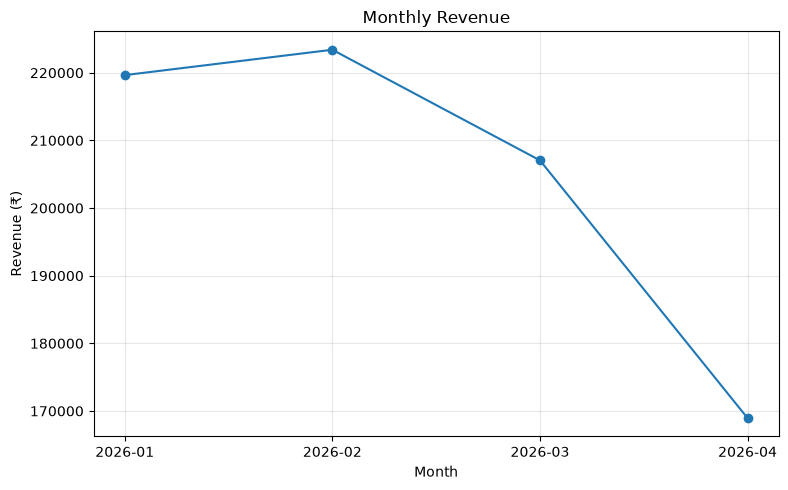

In [168]:
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


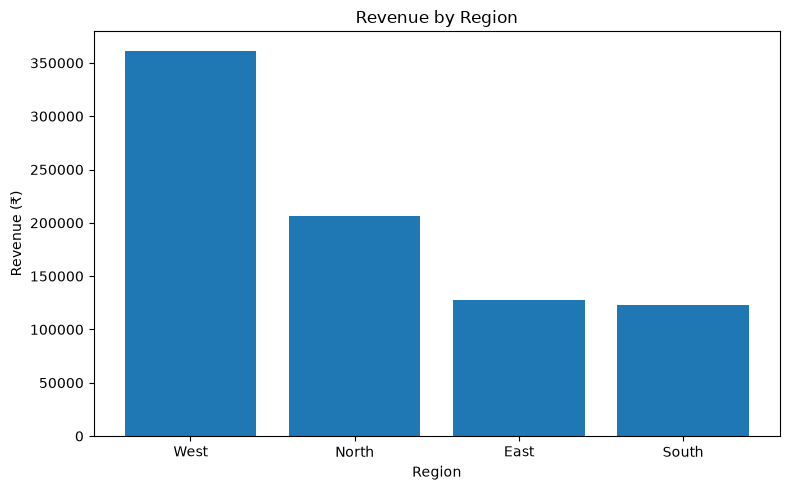

In [169]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis.index,
    region_analysis["revenue"]
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

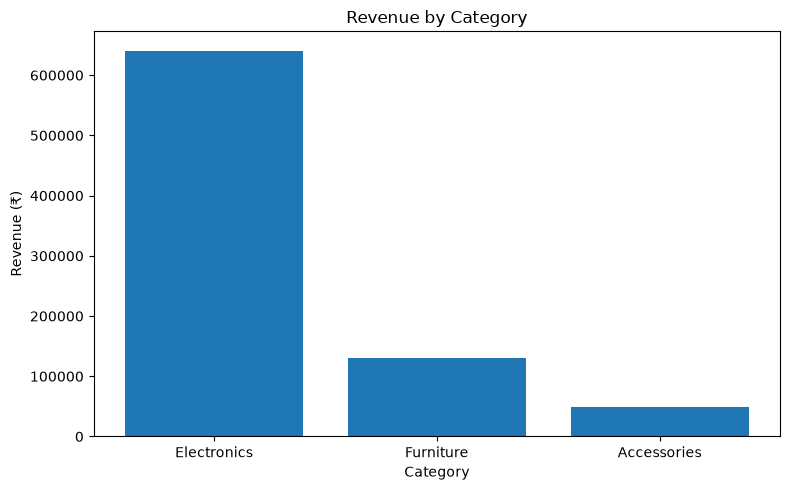

In [170]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis["revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

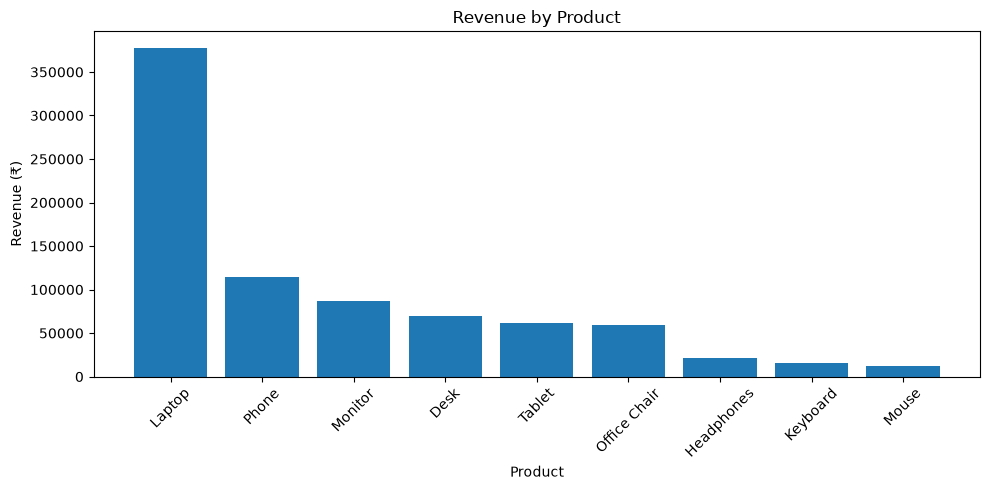

In [171]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_analysis.index,
    product_analysis["revenue"]
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

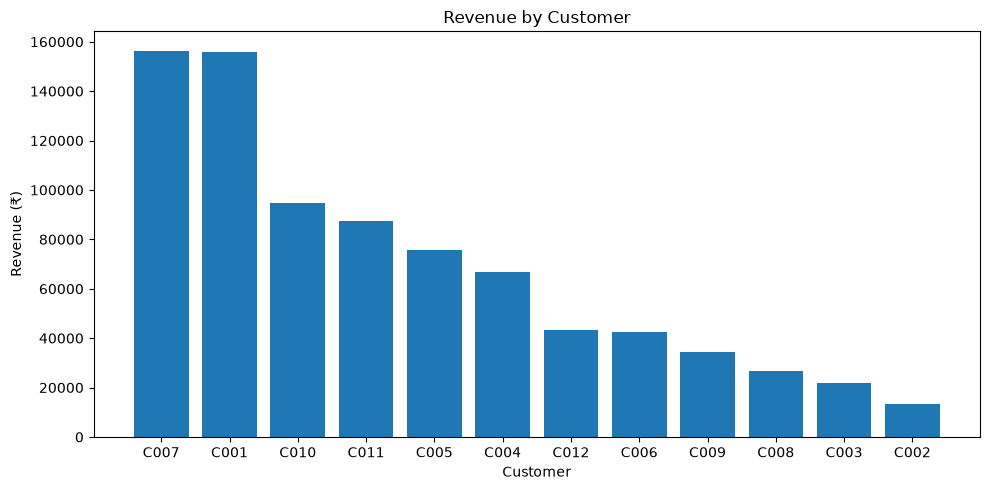

In [172]:
plt.figure(figsize=(10, 5))

plt.bar(
    customer_analysis.index,
    customer_analysis["revenue"]
)

plt.title("Revenue by Customer")
plt.xlabel("Customer")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

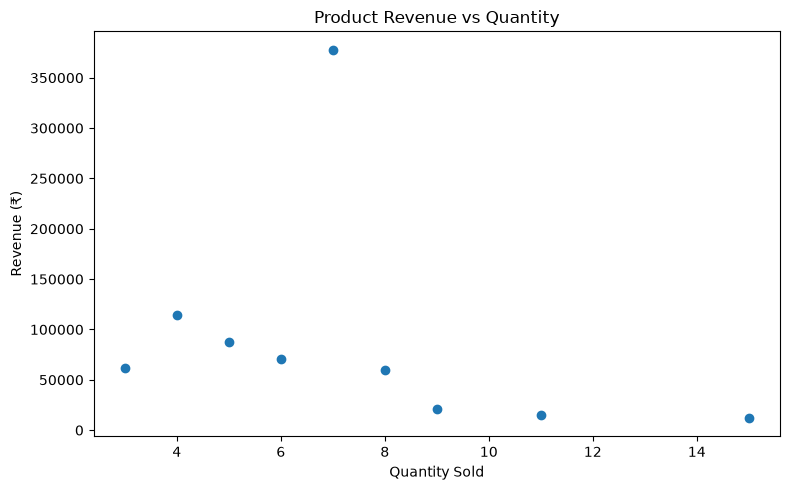

In [173]:
plt.figure(figsize=(8, 5))

plt.scatter(
    product_analysis["quantity"],
    product_analysis["revenue"]
)

plt.title("Product Revenue vs Quantity")
plt.xlabel("Quantity Sold")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

# Business Insights

1. Revenue peaked in February at ₹223,400 and declined over the following two months. April recorded the lowest revenue of ₹168,950, representing an 18.40% MoM decline.

2. The April revenue decline was primarily associated with lower order volume. Orders decreased from 8 in March to 6 in April, while AOV increased from approximately ₹25,881 to ₹28,158.

3. West generated the highest regional revenue at ₹361,550, contributing 44.14% of total revenue and recording the highest regional AOV.

4. Electronics was the dominant category, generating ₹640,800 and contributing 78.24% of total revenue.

5. Laptop was the strongest revenue-generating product, contributing ₹377,800 or 46.13% of total revenue despite only 7 units being sold.

6. Customer revenue was concentrated among high-value customers. The 5 customers classified as High Value generated approximately 69.60% of total revenue.

7. Sales volume did not directly translate into higher revenue. Mouse recorded the highest sales volume at 15 units but generated only ₹12,000, while Laptop sold 7 units and generated ₹377,800.

8. Furniture had the highest average discount at approximately 8.13%, compared with 4.69% for Electronics and 3.89% for Accessories. The dataset does not establish that higher discounts caused changes in revenue.

# Business Recommendations

1. Investigate the decline in order volume

April revenue declined by 18.40% MoM while AOV increased. Further investigation should focus on why order volume decreased in April.

2. Reduce dependency on a single product

Laptop generated 46.13% of total revenue. The business should monitor this concentration and explore opportunities to increase revenue contribution from other high-value products.

3. Investigate regional performance differences

West generated the highest revenue and AOV, while South recorded the lowest revenue and AOV. Differences in product mix, order volume and customer behavior should be investigated.

4. Monitor high-value customer concentration

Five High Value customers generated approximately 69.60% of total revenue. Their purchasing patterns and retention should be monitored because a significant portion of revenue comes from this segment.

5. Evaluate discount effectiveness

Furniture had the highest average discount at approximately 8.13%. Discount strategies should be evaluated alongside revenue, order volume and profitability rather than assuming that higher discounts automatically improve performance.

# Conclusion

This project analyzed 30 sales transactions using Python and Pandas to understand revenue performance across products, customers, categories, regions, discounts and time.

The analysis identified a declining revenue trend after February, strong revenue concentration in Electronics and Laptop sales, significant contribution from high-value customers, and substantial regional differences.

The project demonstrates an end-to-end data analytics workflow:

Raw Data → Data Cleaning → Feature Engineering → KPI Analysis → EDA → Visualization → Business Insights → Recommendations